In [1]:
import numpy as np
import matplotlib.pyplot as plt
from plot import make_theme

%matplotlib inline
plt.rcParams['font.size'] = 7

In [2]:
def plot_label(ax, count, x=0, y=1.03, color='k'):
    ax.text(x, y, count, fontdict=dict(fontsize=9), transform=ax.transAxes, color=color, weight='bold')

# REIXS

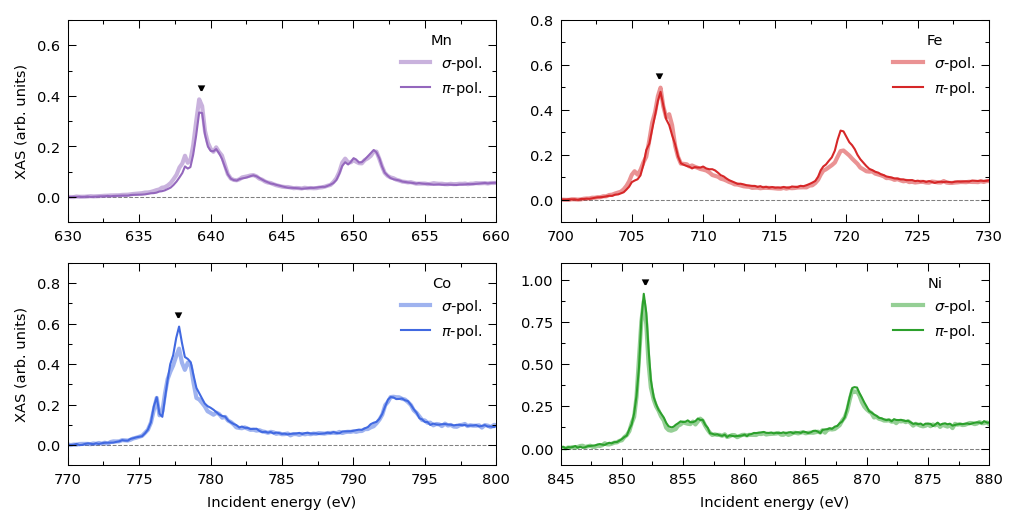

In [3]:
fig, axs = plt.subplots(2, 2, figsize=(6.75,6.75/2), dpi=150, gridspec_kw=dict(wspace=0.15, hspace=0.2, left=0.07, right=0.98, bottom=0.1, top=0.98))

# th=20
edges = ['Mn', 'Fe', 'Co', 'Ni']
energies = [639.3, 706.9, 777.7, 851.9]
colors = ['C4','C3','royalblue','C2']
for ax, edge, energy, color in zip(axs.ravel(), edges, energies, colors):
    # sigma
    data = dict(np.load('../reixs/data/xas_'+edge+'_sigma.npz'))
    x, y = data['x'][::-1], data['y'][::-1]-np.min(data['y'])
    ax.plot(x, y, ls='-', lw=2, alpha=0.5, zorder=-1, color=color, label='$\sigma$-pol.')
    ymax = [np.interp(energy, x, y)]
    # pi
    data = dict(np.load('../reixs/data/xas_'+edge+'_pi.npz'))
    x, y = data['x'][::-1], data['y'][::-1]-np.min(data['y'])
    ax.plot(x, y, ls='-', lw=1, alpha=1, zorder=1, color=color, label='$\pi$-pol.')
    ymax.append(np.interp(energy, x, y))
    # peak energy
    ax.plot(energy, np.max(ymax)*1.15, 'vk', ms=2)
    ax.axhline(y=0., ls='--', lw=0.5, color='gray', zorder=-10)
    ax.legend(title=edge, loc='upper right', frameon=False)

for ax in axs.ravel():
    make_theme(ax, ticklength=4)
axs[0,0].set_xlim(630,660)
axs[0,0].set_ylim(-0.1,0.7)
axs[0,1].set_xlim(700,730)
axs[0,1].set_ylim(-0.1,0.8)
axs[1,0].set_xlim(770,800)
axs[1,0].set_ylim(-0.1,0.9)
axs[1,1].set_xlim(845,880)
axs[1,1].set_ylim(-0.1,1.1)
for ax in axs[:,0]:
    ax.set_ylabel('XAS (arb. units)')
for ax in axs[1]:
    ax.set_xlabel('Incident energy (eV)')
# fig.savefig('xas_reixs.pdf')

# 13-3

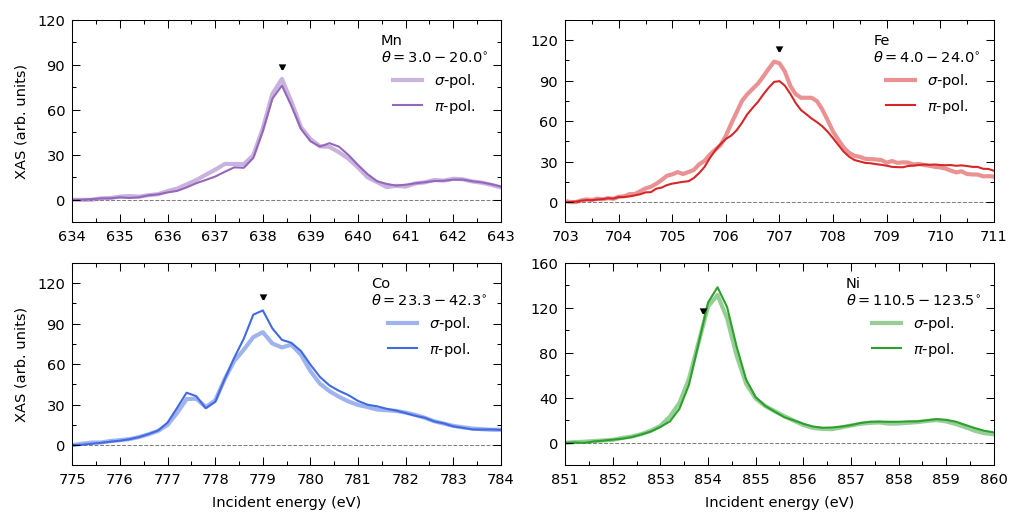

In [4]:
fig, axs = plt.subplots(2, 2, figsize=(6.75,6.75/2), dpi=150, gridspec_kw=dict(wspace=0.15, hspace=0.2, left=0.07, right=0.98, bottom=0.1, top=0.98))

# th=20
edges = ['Mn', 'Fe', 'Co', 'Ni']
energies = [638.4, 707, 779, 853.9]
colors = ['C4','C3','royalblue','C2']
for ax, edge, energy, color in zip(axs.ravel(), edges, energies, colors):
    # sigma
    data = dict(np.load('../13-3/data/xas_'+edge+'_sigma.npz'))
    x, y = data['x'], data['y']-np.min(data['y'])
    ax.plot(x, y, ls='-', lw=2, alpha=0.5, zorder=-1, color=color, label='$\sigma$-pol.')
    ymax = [np.interp(energy, x, y)]
    # pi
    data = dict(np.load('../13-3/data/xas_'+edge+'_pi.npz'))
    x, y = data['x'], data['y']-np.min(data['y'])
    ax.plot(x, y, ls='-', lw=1, alpha=1, zorder=1, color=color, label='$\pi$-pol.')
    ymax.append(np.interp(energy, x, y))
    # peak energy
    ax.plot(energy, np.max(ymax)*1.1, 'vk', ms=2)
    ax.axhline(y=0., ls='--', lw=0.5, color='gray', zorder=-10)
    ax.legend(title=edge+'\n$\\theta={:.1f}-{:.1f}$'.format(np.min(data['th']),np.max(data['th']))+'$^{\circ}$', loc='upper right', frameon=False)

for ax in axs.ravel():
    make_theme(ax, ticklength=4)
axs[0,0].set_xlim(634,643)
axs[0,0].set_ylim(-15,120)
axs[0,0].set_yticks(np.arange(0.,120.1,30.))
axs[0,1].set_xlim(703,711)
axs[0,1].set_ylim(-15,135)
axs[0,1].set_yticks(np.arange(0.,130.1,30.))
axs[1,0].set_xlim(775,784)
axs[1,0].set_ylim(-15,135)
axs[1,0].set_yticks(np.arange(0.,130.1,30.))
axs[1,1].set_xlim(851,860)
axs[1,1].set_ylim(-20,160)
axs[1,1].set_yticks(np.arange(0.,160.1,40.))
for ax in axs[:,0]:
    ax.set_ylabel('XAS (arb. units)')
for ax in axs[1]:
    ax.set_xlabel('Incident energy (eV)')
# fig.savefig('xas_13-3.pdf')